# PROBABILITY

In [52]:
pip install statsmodels


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [76]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

SEED = 42
rng = np.random.default_rng(SEED)

#setting significance level for hypothesis testing
alpha = 0.05

pd.set_option('display.precision', 4)
print("Setup Complete")

Setup Complete


## 4. One-sample t-test
### Coffee-shop wait-time scenario

Deck hypothesis:
- **H0:** u=3 minutes
- **H1:** u!=3 minutes

In [77]:
wait_times = np.array([
    4.2, 3.8, 3.5, 4.0, 4.5, 3.3, 4.2, 4.1, 3.9, 4.3,
    3.7, 4.0, 4.2, 3.8, 3.6, 4.1, 3.9, 4.4, 4.0, 4.2,
    3.7, 3.9, 4.0, 4.1, 4.3, 3.6, 3.9, 4.0, 4.2, 4.2,
    3.8, 3.5, 4.0, 4.5, 3.3, 4.2, 4.1, 3.9, 4.3, 3.7,
    4.0, 4.2, 3.8, 3.6, 4.1, 3.9, 4.4, 4.0, 4.2, 3.7,
    3.9, 4.0, 4.1, 4.3, 3.6, 3.9, 4.0, 4.2
])

In [78]:
hypothesized_mean = 3.0

print(f"Observations used:n={len(wait_times)}")
print(f"Sample mean: {wait_times.mean():.4f}")
print(f"Sample standard deviation: {wait_times.std(ddof=1):.4f}")

Observations used:n=58
Sample mean: 3.9793
Sample standard deviation: 0.2758


In [79]:
t_stat, p_value = stats.ttest_1samp(wait_times, popmean=hypothesized_mean)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6g}")

T-statistic: 27.0439
P-value: 3.3377e-34


In [80]:
def hypothesis_desision(p_value:float, alpha:float=0.05)->str:
    if p_value < alpha:
        return f"Reject H0(p={p_value:.4g}<= alpha={alpha})"
    else:
        return f"Fail to reject H0(p={p_value:.4g}> alpha={alpha})"



In [81]:
hypothesis_desision(p_value, alpha)

'Reject H0(p=3.338e-34<= alpha=0.05)'

### we reject the null hypothesis at a level of significance alpha=0.05 and conclude that average waiting time of coffee is not 3 mins

In [82]:
iris_data=pd.read_csv("/Users/arjunaji/BIA ARJUN/LIBRABIES/iris.csv")

In [83]:
iris_data.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


### is there any signifiacance btwn sepal length oif iris  setosa and iris virginica

- H0 : There is no significant difference between speal length
- H1 : There is significant diference btwn sepal length of setosa and virginica

In [84]:
setosa_sepal_length = iris_data[iris_data['variety'] == 'Setosa']['sepal.length']
versicolor_sepal_length = iris_data[iris_data['variety'] == 'Versicolor']['sepal.length']

In [85]:
#perform 2 sample t-test
t_stat, p_value = stats.ttest_ind(setosa_sepal_length, versicolor_sepal_length)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6g}")

T-statistic: -10.5210
P-value: 8.98524e-18


In [86]:
hypothesis_desision(p_value, alpha)

'Reject H0(p=8.985e-18<= alpha=0.05)'

### we reject null hypothesis which means setosa and virginica have significant difference in sepal legth

In [87]:
# checking the sepal length and sepal width relationship for all three species using correlation
corr= stats.pearsonr(iris_data['sepal.length'], iris_data['sepal.width'])
print(f"Pearson correlation coefficient: {corr[0]:.4f}")

Pearson correlation coefficient: -0.1176


##### THERE IS A WEAK NEGATIVE CORRELATION THAT EXISTS BTWN SEPAL LENGTH AND SEPAL WIDTH

In [88]:
# calculate correlation using pandas
numeric_data = iris_data[['sepal.length', 'sepal.width', 'petal.length', 'petal.width']]
numeric_data.corr()

,sepal.length,sepal.width,petal.length,petal.width
sepal.length,1.0000,-0.1176,0.8718,0.8179
sepal.width,-0.1176,1.0000,-0.4284,-0.3661
petal.length,0.8718,-0.4284,1.0000,0.9629
petal.width,0.8179,-0.3661,0.9629,1.0000


<Axes: >

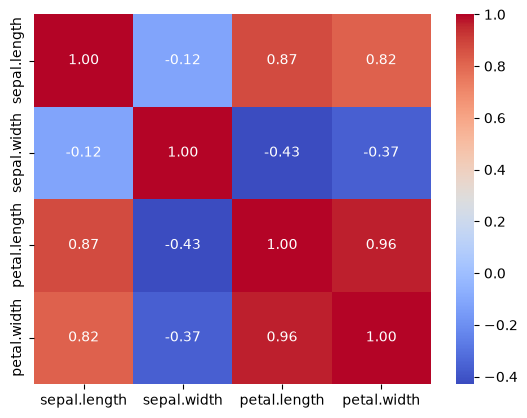

In [89]:
# visualtise the correlation mattrix using a heatmap
import seaborn as sns

corr_matrix = numeric_data.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

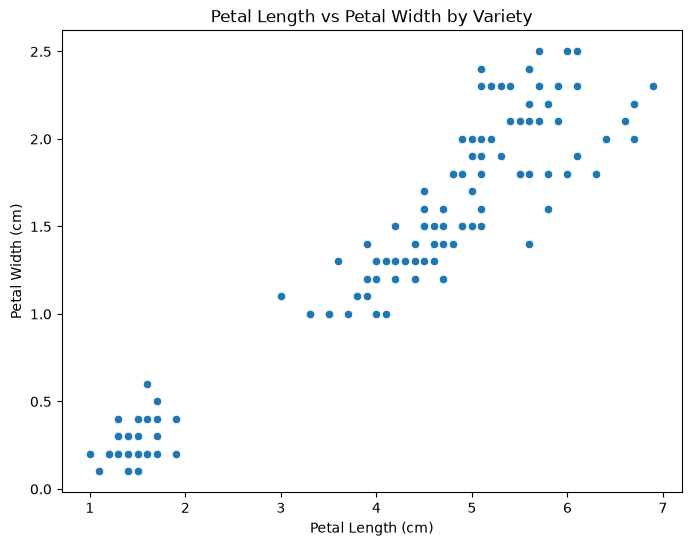

In [90]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=iris_data, x='petal.length', y='petal.width')
plt.title('Petal Length vs Petal Width by Variety')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.show()

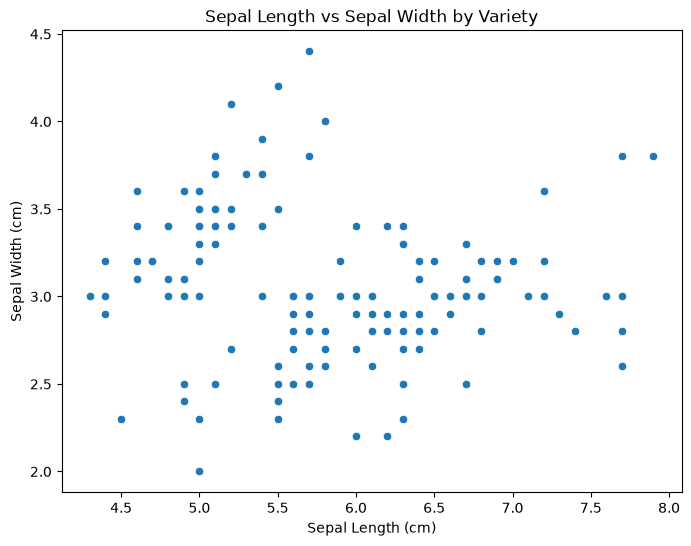

In [91]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=iris_data, x='sepal.length', y='sepal.width')
plt.title('Sepal Length vs Sepal Width by Variety')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.show()

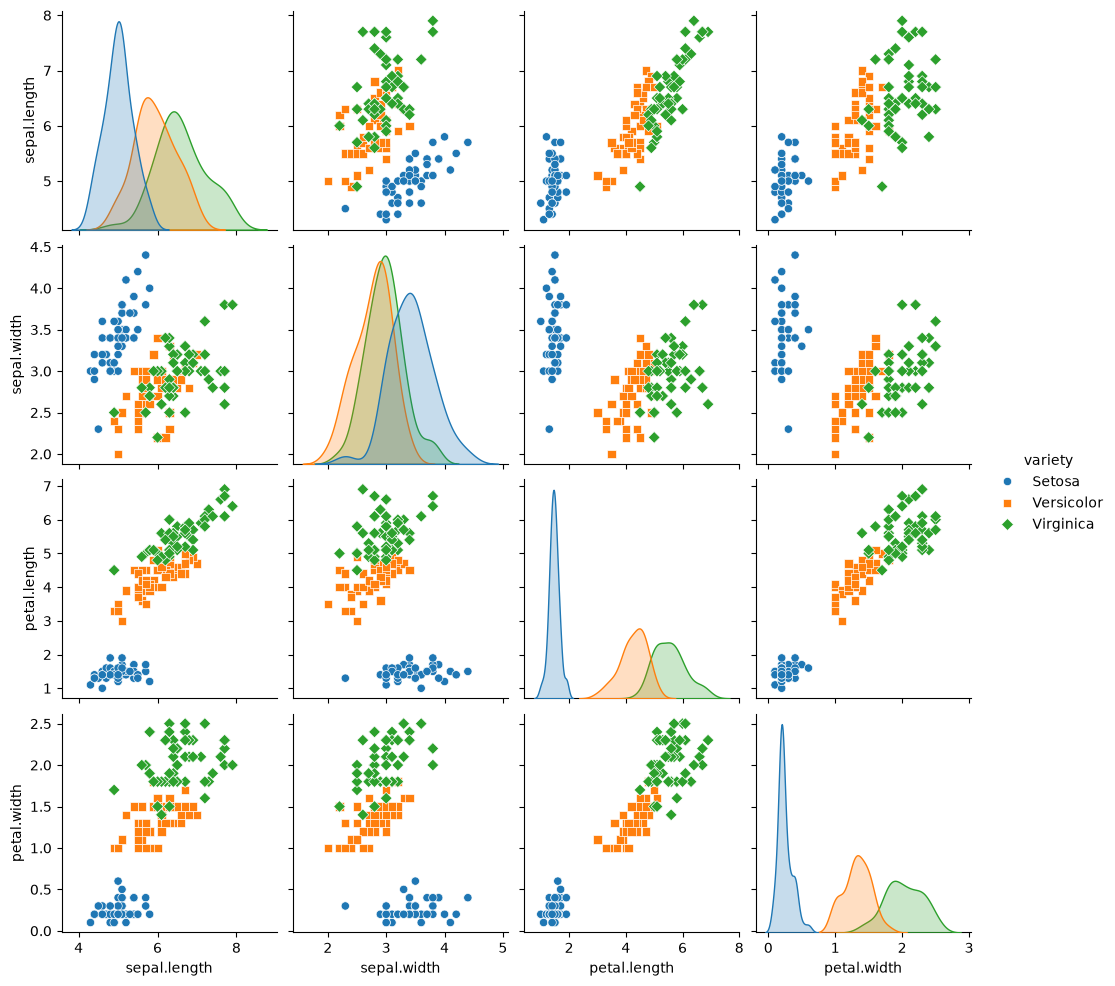

In [92]:
sns.pairplot(iris_data, markers=["o","s","D"],hue='variety')

# Chi-square test for catagorical data
### Test of independence

- H0: gender and voting preferences are independent
- H1: they are associated

A fixed contigency table makes the demo reproducible and lets us inspect the expected counts

In [93]:
observed = pd.DataFrame(
    {
        "Candidate A": [45,25],
        "Candidate B": [30,50],
        "Candidate C": [25,25]
    },
    index=["Male","Female"]
)
display(observed)

,Candidate A,Candidate B,Candidate C
Male,45,30,25
Female,25,50,25


In [95]:
chi2_stat, p_value,dof,expected=stats.chi2_contingency(observed)

expected_df=pd.DataFrame(
    expected,
    index=observed.index,
    columns=observed.columns
)

print(f"chi-sqr statitic:{chi2_stat:.4f}")
print(f"degree of freedom:{dof}")
print(f"p-value:{p_value:.6f}")
print(hypothesis_desision(p_value,alpha))
print("\nExpected count under H0:")
display(expected_df.round(2))

chi-sqr statitic:10.7143
degree of freedom:2
p-value:0.004714
Reject H0(p=0.004714<= alpha=0.05)

Expected count under H0:


,Candidate A,Candidate B,Candidate C
Male,35.0,40.0,25.0
Female,35.0,40.0,25.0


- H0: there no significant diff btwn sepal length btwn species
- H1: there is significant diff btwn sepal length btwn species

In [99]:
setosa_sepal_length = iris_data[iris_data['variety'] == 'Setosa']['sepal.length']
versicolor_sepal_length = iris_data[iris_data['variety'] == 'Versicolor']['sepal.length']
virginica_sepal_length = iris_data[iris_data['variety'] == 'Virginica']['sepal.length']

f_stat,p_value= stats.f_oneway(setosa_sepal_length,versicolor_sepal_length,virginica_sepal_length)

print(f"one way anova:{f_stat:.4f}")
print(f"p-value:{p_value:.6g}")
print(hypothesis_desision(p_value,alpha))

one way anova:119.2645
p-value:1.66967e-31
Reject H0(p=1.67e-31<= alpha=0.05)


### null hypothesis rejected as there is significant difference in sepal length of the 3

In [100]:
iris_data.groupby('variety')['sepal.length'].mean()

variety
Setosa        5.006
Versicolor    5.936
Virginica     6.588
Name: sepal.length, dtype: float64